# Explicabilidad de modelos

La explicabilidad hace referencia a la capacidad de aproximar, reconstruir o justificar las decisiones de un modelo complejo u opaco mediante el uso de interfaces o métodos analíticos auxiliares aplicados a posteriori.

**Problema:** Estimación del riesgo de evento adverso en cuidados críticos. El objetivo central no es ordenar pacientes (discriminación), sino obtener probabilidades insesgadas para dosificar soporte invasivo sin provocar iatrogenia. Identificación de factores asociados a eventos adversos.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [2]:
np.random.seed(42)
n_samples = 6000

edad = np.random.normal(62, 12, n_samples).clip(18, 95).round()
presion_arterial_media = np.random.normal(75, 14, n_samples)
lactato = np.random.exponential(1.8, n_samples)
creatinina = np.random.lognormal(0.2, 0.4, n_samples)

log_odds = (
    -4.5 
    + 0.03 * edad 
    - 0.04 * presion_arterial_media 
    + 0.65 * lactato 
    + 0.50 * creatinina
)
prob_real = 1 / (1 + np.exp(-log_odds))
evento_adverso = np.random.binomial(1, prob_real)

df_salud = pd.DataFrame({
    'edad': edad,
    'pam': presion_arterial_media,
    'lactato': lactato,
    'creatinina': creatinina,
    'evento': evento_adverso
})

df_salud.head()

,edad,pam,lactato,creatinina,evento
0,68.0,59.402861,0.848297,0.874261,0
1,60.0,66.166968,1.551492,0.641422,0
2,70.0,61.811157,1.039367,1.054580,0
3,80.0,67.328059,0.031497,1.913986,0
4,59.0,72.001896,9.208113,1.587855,1


In [3]:
X = df_salud.drop(columns='evento')
y = df_salud['evento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

## Modelos interpretables

Modelos como regresión logística y árboles de decisión son interpretables porque en ellos es posible saber el mecanismo matemático interno y la lógica causal exacta mediante la cual las entradas se transforman en salidas.

### Regresión logística

In [4]:
model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    class_weight='balanced',
    )

random_search = RandomizedSearchCV(
    model,
    param_distributions={
        'C': np.logspace(-4, 4, 20),
        'l1_ratio': np.linspace(0, 1, 10),
    },
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print(classification_report(y_test, best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90      1138
           1       0.19      0.76      0.31        62

    accuracy                           0.82      1200
   macro avg       0.59      0.79      0.60      1200
weighted avg       0.94      0.82      0.87      1200



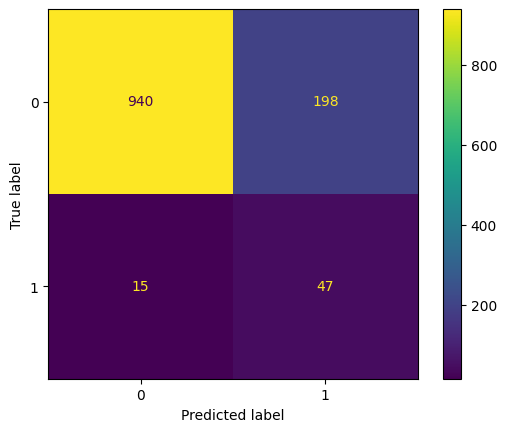

In [5]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test);

In [6]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': best_model.coef_[0]
}).sort_values(by='coef', key=abs, ascending=False)

coef_df = pd.concat([
    pd.DataFrame({'feature': ['intercept'], 'coef': [best_model.intercept_[0]]}),
    coef_df
], ignore_index=True)

coef_df.sort_values(by='coef', key=abs, ascending=False, inplace=True)
coef_df

,feature,coef
1,lactato,0.650631
2,creatinina,0.508969
0,intercept,-0.419915
3,pam,-0.046287
4,edad,0.017117


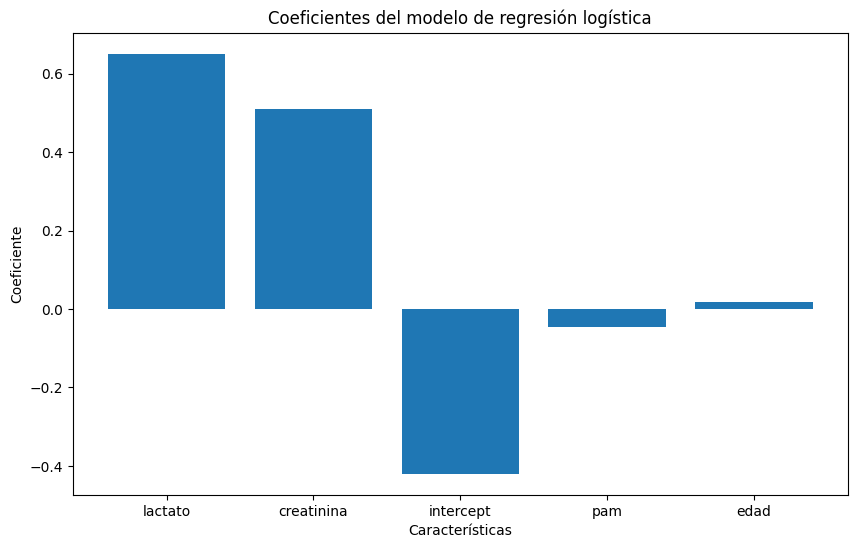

In [7]:
plt.figure(figsize=(10, 6))
plt.bar(coef_df['feature'], coef_df['coef'])
plt.title('Coeficientes del modelo de regresión logística')
plt.xlabel('Características')
plt.ylabel('Coeficiente')
plt.show()

### Árbol de decisión

In [8]:
model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
)

random_search_tree = RandomizedSearchCV(
    model,
    param_distributions={
        'max_depth': np.arange(1, 20),
        'min_samples_split': np.arange(2, 20),
        'min_samples_leaf': np.arange(1, 20),
    },
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
)

random_search_tree.fit(X_train, y_train)

best_model_tree = random_search_tree.best_estimator_

print(classification_report(y_test, best_model_tree.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.79      0.88      1138
           1       0.17      0.79      0.28        62

    accuracy                           0.79      1200
   macro avg       0.58      0.79      0.58      1200
weighted avg       0.94      0.79      0.85      1200



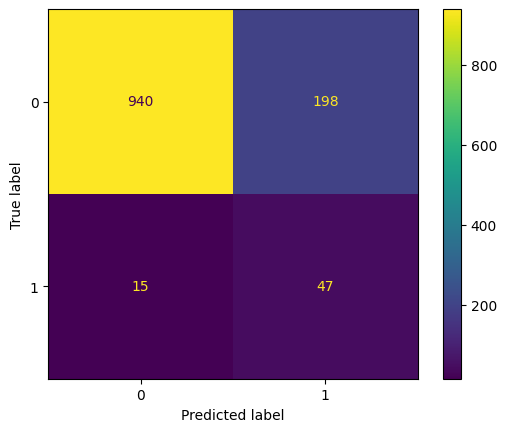

In [9]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test);

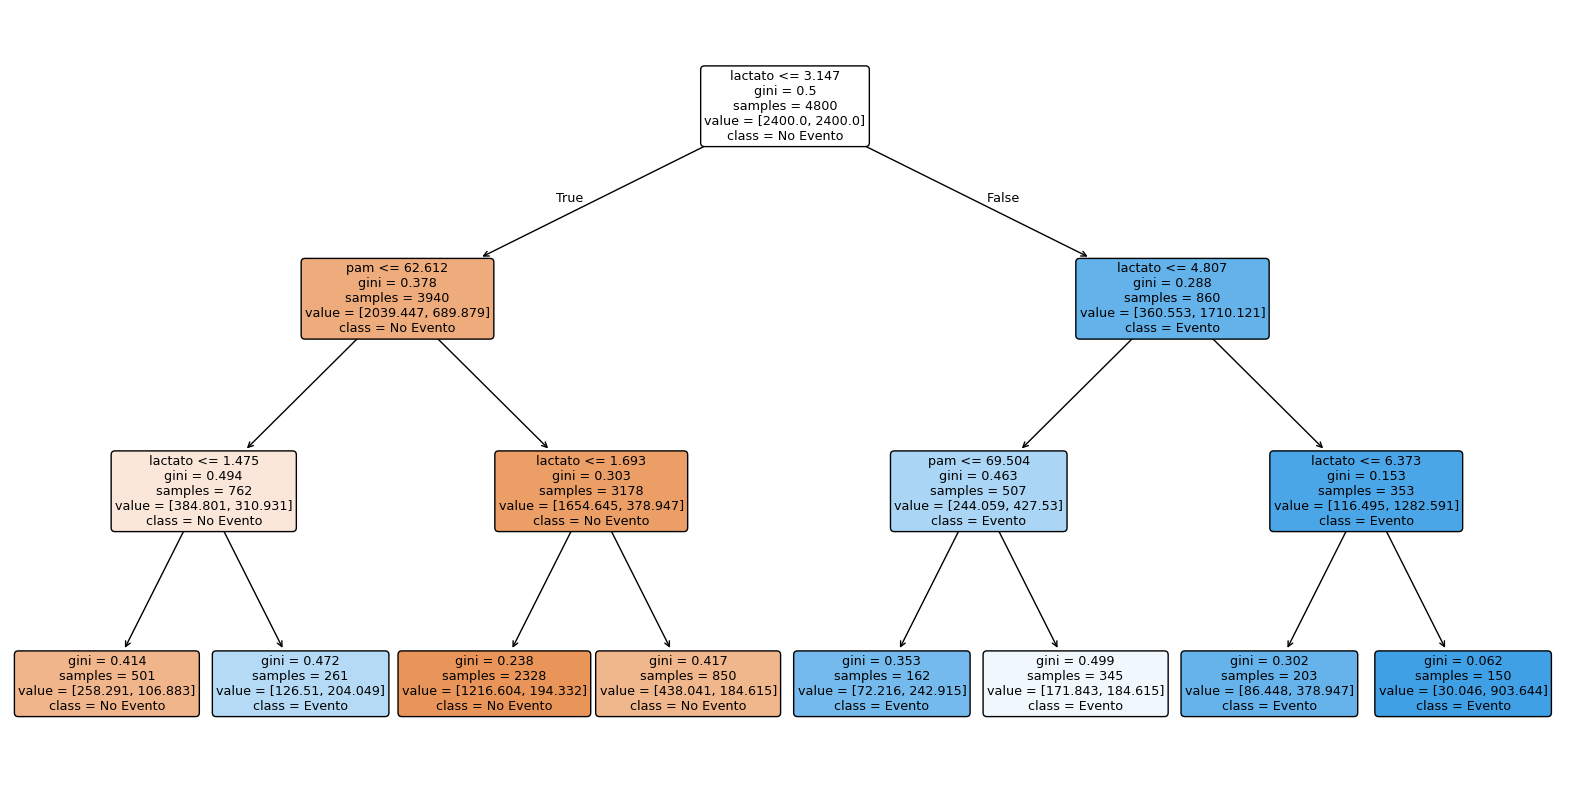

In [10]:
plt.figure(figsize=(20, 10))
plot_tree(best_model_tree, feature_names=X.columns, class_names=['No Evento', 'Evento'], filled=True, rounded=True)
plt.show()

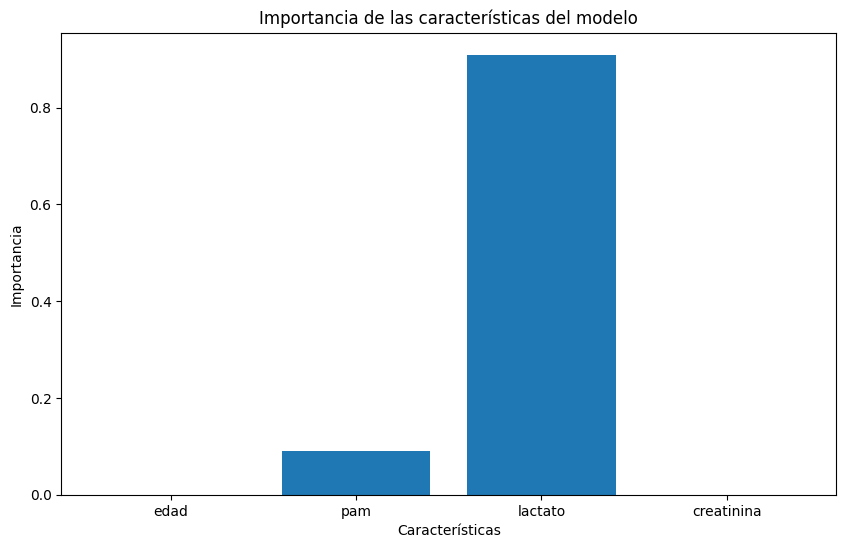

In [11]:
# Gráfico de barras de la importancia de las características del modelo
importances = best_model_tree.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(X.columns, importances)
plt.title('Importancia de las características del modelo')
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.show()

## Modelos de caja negra

Procedemos a entrenar un modelo de caja negra:

In [12]:
model = HistGradientBoostingClassifier(
    random_state=42,
    class_weight='balanced',
    )

randon_search = RandomizedSearchCV(
    estimator=model,
    param_distributions={
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'min_samples_leaf': [20, 50, 100]
    },
    n_iter=10,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

randon_search.fit(X_train, y_train)

base_model = randon_search.best_estimator_

modelo_calibrado = CalibratedClassifierCV(
    estimator=base_model, 
    cv=5, 
    method='sigmoid'
    )

modelo_calibrado.fit(X_train, y_train)

probs_cal = modelo_calibrado.predict_proba(X_test)[:, 1]

preds_final = (probs_cal >= 0.05).astype(int)

print(classification_report(y_test, preds_final))


              precision    recall  f1-score   support

           0       0.98      0.82      0.89      1138
           1       0.19      0.76      0.30        62

    accuracy                           0.82      1200
   macro avg       0.59      0.79      0.60      1200
weighted avg       0.94      0.82      0.86      1200



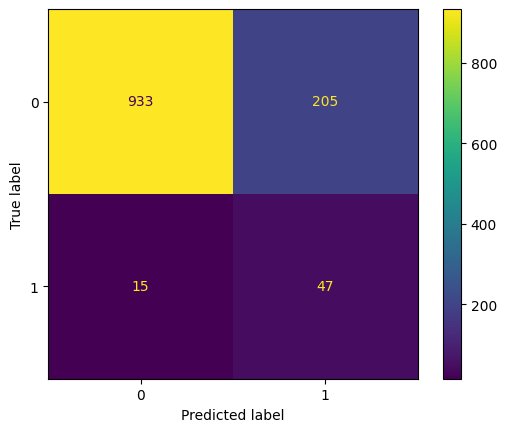

In [13]:
ConfusionMatrixDisplay.from_predictions(y_test, preds_final);

Este modelo no es explicable.

## Añadiendo una capa de explicabilidad con SHAP

In [14]:
import shap

explainer = shap.TreeExplainer(base_model)

# Cálculo de valores SHAP sobre el conjunto de prueba
# Retorna los valores de atribución en el espacio de log-odds (margen del modelo)
shap_values = explainer(X_test)

# Si el estimador genera salidas multidimensionales (clase 0 y clase 1),
# seleccionamos la dimensión correspondiente a la clase positiva (evento adverso):
if len(shap_values.shape) == 3:
    shap_values_target = shap_values[:, :, 1]
else:
    shap_values_target = shap_values

### Explicabilidad global

En SHAP, la explicabilidad global agrega los valores de atribución locales calculados para cada observación con el fin de ofrecer una panorámica del comportamiento del modelo sobre toda la población de prueba.

Los dos gráficos globales canónicos son el Diagrama de Importancia Media Absoluta (Bar Plot) y el Diagrama de Enjambre (Beeswarm Plot).

**Diagrama de Barras de Importancia Media Global (Bar Plot)**

Este gráfico sintetiza la relevancia de cada variable ordenándolas de mayor a menor según su impacto global promedio en la salida del modelo.

- Eje Vertical (Variables): Lista las características disponibles ordenadas de arriba hacia abajo, donde la superior es la más influyente.
- Eje Horizontal ($\text{mean}(\vert{}\text{SHAP value}\vert{})$): Muestra el promedio de las magnitudes absolutas de los valores SHAP:

$$I_j = \frac{1}{N} \sum_{i=1}^N \vert{}\phi_j^{(i)}\vert{}$$

**Regla de interpretación:**

- Se toma el valor absoluto ($\vert{}\phi_j\vert{}$) para evitar que los efectos positivos y negativos se cancelen entre sí.
- Una barra más larga indica que la variable desplaza fuertemente las predicciones (hacia arriba o hacia abajo) respecto al valor base.
- Limitación crítica: Este gráfico no muestra la dirección del efecto. Informa cuánto altera la variable el resultado, pero no si valores altos de la variable incrementan o reducen la probabilidad del desenlace.

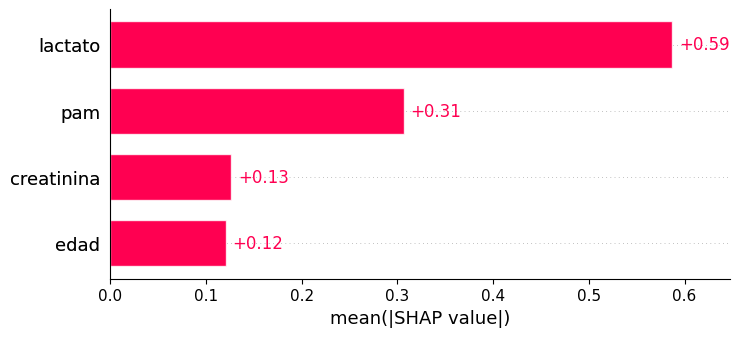

In [15]:
shap.plots.bar(shap_values_target, show=False);

**Diagrama de Enjambre (Beeswarm Plot)**

Es la visualización global más completa de SHAP, ya que integra en una sola vista la importancia relativa, la direccionalidad del efecto, la dispersión y la presencia de relaciones no lineales.

Elementos del gráfico y su lectura:

- Eje Vertical (Variables): Al igual que en el gráfico de barras, las variables están ordenadas jerárquicamente por importancia decreciente (la superior es la de mayor impacto global).
- Eje Horizontal (SHAP Value / Impact on Model Output):Representa el valor de atribución $\phi_j$ en la escala del modelo (habitualmente en log-odds para clasificación binaria).
    - Cero ($\phi_j = 0$): Es la línea vertical neutral. Significa que para esa instancia la variable no alteró la predicción respecto a la base esperada $E[f(X)]$.
    - Hacia la derecha ($\phi_j > 0$): La variable empuja la predicción hacia la clase positiva (mayor probabilidad de evento o riesgo).
    - Hacia la izquierda ($\phi_j < 0$): La variable empuja la predicción hacia la clase negativa (menor probabilidad de evento).
- Puntos individuales:
    - Cada punto en el gráfico representa una instancia u observación única (un paciente, un estudiante, un sensor).
    - La acumulación vertical o "engrosamiento" de puntos a modo de enjambre indica una alta densidad de observaciones compartiendo un impacto similar.
    - Mapa de Color (Valor de la Característica / Feature Value): 
        - Rojo: Valor numérico alto de la variable en esa observación (relativo a su propia distribución).
        - Azul: Valor numérico bajo de la variable.
        - Púrpura / Intermedio: Valores cercanos a la media poblacional.

<Axes: xlabel='SHAP value (impact on model output)'>

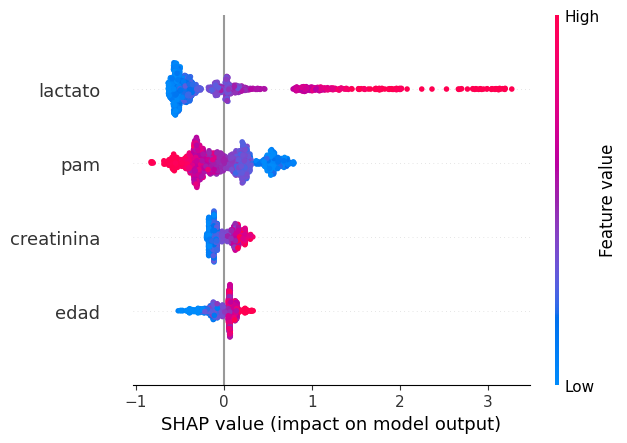

In [16]:
shap.plots.beeswarm(shap_values_target, show=False, plot_size=None)

### Explicabilidad local

El gráfico de explicabilidad local por excelencia en SHAP es el Diagrama en Cascada (Waterfall Plot). A diferencia de los gráficos globales, que resumen el comportamiento de toda la población, el gráfico local actúa como una auditoría forense sobre una única instancia u observación específica.

Al proyectar un Waterfall Plot, se observan los siguientes componentes de abajo hacia arriba:

- La Base Inferior ($E[f(X)]$): Es el punto de partida del diagrama. Indica la tasa base o promedio de la población. Si no tuviéramos ningún dato del paciente, este sería el valor predicho.
- El Eje Vertical (Variables y Valores Reales): A la izquierda de cada fila se indica el nombre de la variable acompañado del valor real numérico o categórico que tuvo esa observación. Las características aparecen ordenadas de mayor a menor según la magnitud absoluta de su contribución ($\vert{}\phi_j\vert{}$): las variables que más alteraron la decisión aparecen en la parte superior.
- Las Barras Horizontales (Vectores de Empuje):
    - Color Rojo (Valores Positivos, $+ \phi_j$): Indican variables cuyo valor específico empujó la predicción hacia arriba (incrementó el riesgo o la probabilidad de pertenecer a la clase positiva).
    - Color Azul (Valores Negativos, $- \phi_j$): Indican variables cuyo valor específico empujó la predicción hacia abajo (protegió al individuo o redujo la probabilidad del evento).
    - Longitud de la barra: Representa exactamente la magnitud numérica del valor $\phi_j$.
- El Tope Superior ($f(x)$):Es la predicción final resultante. Es la suma algebraica exacta del valor base más cada una de las barras rojas menos las barras azules.

Veamos un waterfall plot de un paciente correctamente diagnosticado:

--- EXPLICACIÓN LOCAL: PACIENTE 2310 (VERDADERO POSITIVO) ---


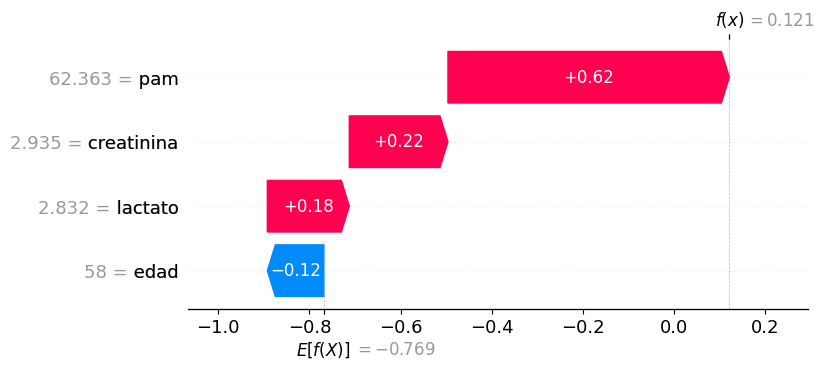

In [17]:
# Identificamos los índices de un Falso Positivo y un Verdadero Positivo representativos
y_pred_base = base_model.predict(X_test)

idx_verdadero_positivo = (y_test == 1) & (y_pred_base == 1)

ejemplo_tp = X_test[idx_verdadero_positivo].index[0]

posicion_tp = X_test.index.get_loc(ejemplo_tp)

print(f"--- EXPLICACIÓN LOCAL: PACIENTE {ejemplo_tp} (VERDADERO POSITIVO) ---")

shap.plots.waterfall(shap_values_target[posicion_tp])

Ahora veamos un caso de un falso positivo:

--- EXPLICACIÓN LOCAL: PACIENTE 3621 (FALSO POSITIVO) ---


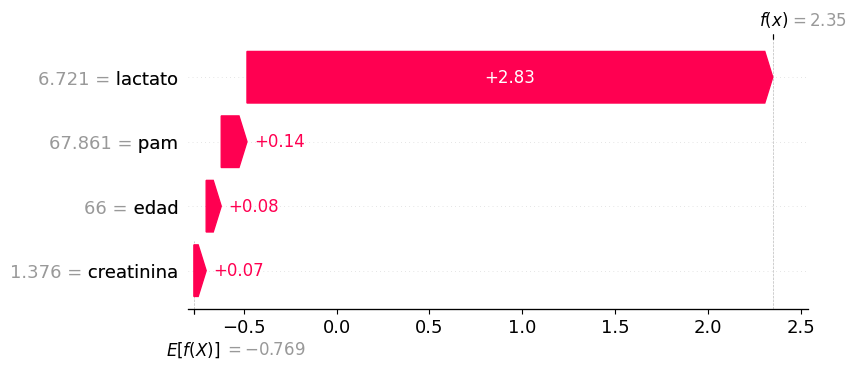

In [18]:
idx_falso_positivo = (y_test == 0) & (y_pred_base == 1)

ejemplo_fp = X_test[idx_falso_positivo].index[0]

posicion_fp = X_test.index.get_loc(ejemplo_fp)

print(f"--- EXPLICACIÓN LOCAL: PACIENTE {ejemplo_fp} (FALSO POSITIVO) ---")

shap.plots.waterfall(shap_values_target[posicion_fp])